# 재정대응지수 구축 및 재정반응성 기초분석

- 작성자: 이정연
- 관련 이슈: #62
- 분석 단위: 17개 시도 × 2016~2024년
- 범위: 전체 계획예산 기반 잠정 지수 구축

## 분석 배경과 방법

이전 출산동향과 다음 해 예산편성의 시차적 관계를 분석할 기초 패널을 만든다.

### 주요 가정

- 예산은 2020년 가격으로 실질화한다.
- 실질예산을 자연로그로 변환한 뒤 전체 지역×연도 기준으로 표준화한다.
- 출산동향은 예산편성 이전 값만 사용한다.
- 총세출 비율의 주 분모는 지역통합 3개 회계 당초예산 순계다.
- 원자료 누락 관측치는 보정하지 않고 표시한다.

### 1. 분석 환경 설정

In [1]:
from pathlib import Path
import sys
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font_candidates = ("AppleGothic", "Malgun Gothic", "NanumGothic")
KOREAN_FONT = next(
    (font for font in korean_font_candidates if font in installed_fonts),
    "sans-serif",
)
plt.rcParams.update({"font.family": KOREAN_FONT, "axes.unicode_minus": False})

np.random.seed(42)

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    path for path in (current_dir, *current_dir.parents) if (path / "pyproject.toml").exists()
)

PANEL_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_시도별_계획예산_합계출산율_기초패널.csv"
)
CPI_PATH = PROJECT_ROOT / "data/lookup/연도별_소비자물가지수_2024기준.csv"
DENOMINATOR_PATH = PROJECT_ROOT / "data/processed/analysis/2016-2024_시도별_총세출_분모_패널.csv"
FISCAL_PANEL_OUTPUT_PATH = PROJECT_ROOT / "data/processed/analysis/2016-2024_재정대응지수_패널.csv"
MODEL_SAMPLE_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2018-2024_재정반응성_회귀표본.csv"
)
MODEL_RESULT_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2018-2024_재정반응성_고정효과_결과.csv"
)
REGION_MAP_PATH = PROJECT_ROOT / "data/lookup/시도_지역코드_매핑.csv"
POPULATION_PATH = next(
    path
    for path in (PROJECT_ROOT / "data/raw").rglob("*.xlsx")
    if "청년고용률 원자료" in unicodedata.normalize("NFC", str(path))
    and "1세별_주민등록인구" in unicodedata.normalize("NFC", path.name)
)

START_YEAR = 2016
END_YEAR = 2024
EXPECTED_REGIONS = 17
CPI_BASE_VALUE = 100.0

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.analysis_panel import (  # noqa: E402
    add_fiscal_index_features,
    add_fiscal_response_features,
    add_total_expenditure_ratio,
)
from src.modeling.fiscal_response import run_fiscal_response_models  # noqa: E402

print(f"프로젝트 경로: {PROJECT_ROOT}")
print(f"그래프 한글 글꼴: {KOREAN_FONT}")

프로젝트 경로: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha
그래프 한글 글꼴: AppleGothic


## 데이터

### 2. 입력 데이터 불러오기 및 검증

In [2]:
panel_raw = pd.read_csv(PANEL_PATH)
cpi_raw = pd.read_csv(CPI_PATH)
region_map = pd.read_csv(REGION_MAP_PATH)
population_raw = pd.read_excel(POPULATION_PATH)

display(panel_raw.head(3))
display(cpi_raw[["연도", "소비자물가지수", "기준연도", "출처기관", "조회일"]])
print("기초패널 shape:", panel_raw.shape)
print("소비자물가지수 shape:", cpi_raw.shape)
print("주민등록인구 shape:", population_raw.shape)

,지역,연도,당해계획예산_백만원,세부사업수,예산금액_존재_사업수,예산결측_사업수,예산비수치_사업수,음수예산_사업수,합계출산율,예산_QA_그룹수,예산_QA_일치건수,예산_QA_불일치건수,예산_QA_판정불가건수,예산_QA_허용초과건수,예산_QA_최대절대오차율,원자료_누락주의
0,강원,2016,"966,330.0000",251,250,1,0,0,1.2370,6,3,3,0,0,3.0400,NaN
1,강원,2017,"1,189,656.0000",276,276,0,0,0,1.1230,6,0,0,6,0,NaN,NaN
2,강원,2018,"1,070,709.0000",77,77,0,0,0,1.0670,3,0,0,3,0,NaN,원자료에 자체사업 상세가 없어 세부사업 합계가 과소대표될 수 있음


,연도,소비자물가지수,기준연도,출처기관,조회일
0,2016,83.7868,2024=100,통계청,2026-07-27
1,2017,85.3396,2024=100,통계청,2026-07-27
2,2018,86.7980,2024=100,통계청,2026-07-27
3,2019,87.0685,2024=100,통계청,2026-07-27
4,2020,87.5350,2024=100,통계청,2026-07-27
5,2021,89.8022,2024=100,통계청,2026-07-27
6,2022,94.5903,2024=100,통계청,2026-07-27
7,2023,97.7066,2024=100,통계청,2026-07-27
8,2024,100.0000,2024=100,통계청,2026-07-27


기초패널 shape: (153, 16)
소비자물가지수 shape: (9, 11)
주민등록인구 shape: (3672, 13)


In [3]:
PANEL_KEY = ["지역", "연도"]
required_panel_columns = {
    "지역",
    "연도",
    "당해계획예산_백만원",
    "합계출산율",
    "원자료_누락주의",
}
required_cpi_columns = {"연도", "소비자물가지수", "기준연도"}

assert required_panel_columns.issubset(panel_raw.columns)
assert required_cpi_columns.issubset(cpi_raw.columns)
assert not panel_raw.duplicated(PANEL_KEY).any()
assert not cpi_raw.duplicated(["연도"]).any()
assert panel_raw["연도"].between(START_YEAR, END_YEAR).all()
assert panel_raw["지역"].nunique() == EXPECTED_REGIONS
assert len(panel_raw) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert panel_raw.groupby("연도")["지역"].nunique().eq(EXPECTED_REGIONS).all()
assert panel_raw["당해계획예산_백만원"].notna().all()
assert panel_raw["합계출산율"].between(0, 5).all()
assert cpi_raw["연도"].tolist() == list(range(START_YEAR, END_YEAR + 1))
assert cpi_raw["소비자물가지수"].gt(0).all()
assert cpi_raw["기준연도"].nunique() == 1

input_qa = pd.Series(
    {
        "관측치": len(panel_raw),
        "지역수": panel_raw["지역"].nunique(),
        "연도수": panel_raw["연도"].nunique(),
        "키중복": int(panel_raw.duplicated(PANEL_KEY).sum()),
        "예산결측": int(panel_raw["당해계획예산_백만원"].isna().sum()),
        "출산율결측": int(panel_raw["합계출산율"].isna().sum()),
        "원자료누락주의": int(panel_raw["원자료_누락주의"].notna().sum()),
    },
    name="값",
)
display(input_qa.to_frame())

,값
관측치,153
지역수,17
연도수,9
키중복,0
예산결측,0
출산율결측,0
원자료누락주의,2


### 3. 20~39세 인구 패널 생성

In [4]:
population = population_raw.rename(
    columns={
        "행정구역(시군구)별": "지역명_전체",
        "연령별": "연령",
    }
).copy()
population["연령_숫자"] = pd.to_numeric(
    population["연령"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)

year_columns = {
    column: int(str(column).split()[0])
    for column in population.columns
    if str(column).split()[0].isdigit() and START_YEAR <= int(str(column).split()[0]) <= END_YEAR
}

population_20_39 = population.loc[
    population["연령_숫자"].between(20, 39)
    & population["항목"].eq("총인구수[명]")
    & population["지역명_전체"].ne("전국"),
    ["지역명_전체", "연령_숫자", *year_columns],
].copy()

assert population_20_39["지역명_전체"].nunique() == EXPECTED_REGIONS
assert population_20_39.groupby("지역명_전체")["연령_숫자"].nunique().eq(20).all()

population_panel = (
    population_20_39.groupby("지역명_전체", as_index=False)[list(year_columns)]
    .sum()
    .rename(columns=year_columns)
    .melt(
        id_vars="지역명_전체",
        var_name="연도",
        value_name="20_39세_인구_명",
    )
    .merge(
        region_map[["지역", "지역명_전체"]],
        on="지역명_전체",
        how="left",
        validate="many_to_one",
    )[["지역", "연도", "20_39세_인구_명"]]
    .sort_values(PANEL_KEY)
    .reset_index(drop=True)
)

assert len(population_panel) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert not population_panel.duplicated(PANEL_KEY).any()
assert population_panel["지역"].notna().all()
assert population_panel["20_39세_인구_명"].gt(0).all()

display(population_panel.head())
display(
    population_panel.groupby("연도", as_index=False)["20_39세_인구_명"]
    .sum()
    .rename(columns={"20_39세_인구_명": "전국_20_39세_인구_명"})
)

,지역,연도,20_39세_인구_명
0,강원,2016,370276
1,강원,2017,366102
2,강원,2018,358469
3,강원,2019,351771
4,강원,2020,346364


,연도,전국_20_39세_인구_명
0,2016,14292568
1,2017,14179616
2,2018,14094116
3,2019,13881380
4,2020,13679270
5,2021,13379358
6,2022,13032692
7,2023,12773034
8,2024,12580219


### 4. 예산 실질화 및 잠정 지수 산출

실질예산을 계산한 뒤 자연로그 변환과 전체 분석 대상 기준 표준화를 적용한다.

In [5]:
fiscal_panel = panel_raw.merge(
    cpi_raw[["연도", "소비자물가지수", "기준연도"]],
    on="연도",
    how="left",
    validate="many_to_one",
).merge(
    population_panel,
    on=PANEL_KEY,
    how="left",
    validate="one_to_one",
)
fiscal_panel = add_fiscal_index_features(
    fiscal_panel,
    cpi_base_value=CPI_BASE_VALUE,
    real_price_label="2024년가격",
)

display(
    fiscal_panel[
        PANEL_KEY
        + [
            "당해계획예산_백만원",
            "소비자물가지수",
            "실질계획예산_2024년가격_백만원",
            "20_39세_인구_명",
            "20_39세_1인당_실질예산_원",
            "총액기준_재정대응지수_z",
            "재정대응지수_z",
            "재정대응점수_0_100",
        ]
    ].head(10)
)

,지역,연도,당해계획예산_백만원,소비자물가지수,실질계획예산_2024년가격_백만원,20_39세_인구_명,20_39세_1인당_실질예산_원,총액기준_재정대응지수_z,재정대응지수_z,재정대응점수_0_100
0,강원,2016,"966,330.0000",83.7868,"1,153,320.5752",370276,"3,114,759.1936",-0.5611,-0.3456,52.0760
1,강원,2017,"1,189,656.0000",85.3396,"1,394,025.1632",366102,"3,807,750.7448",-0.3523,0.0548,58.1904
2,강원,2018,"1,070,709.0000",86.7980,"1,233,564.5780",358469,"3,441,202.9436",-0.4870,-0.1469,55.1096
3,강원,2019,"1,610,182.0000",87.0685,"1,849,328.8476",351771,"5,257,195.2992",-0.0409,0.6978,68.0081
4,강원,2020,"1,479,594.0000",87.5350,"1,690,288.1857",346364,"4,880,092.0006",-0.1400,0.5494,65.7425
5,강원,2021,"1,968,341.0000",89.8022,"2,191,863.4907",338241,"6,480,182.7416",0.1463,1.1147,74.3739
6,강원,2022,"1,320,745.8000",94.5903,"1,396,279.8483",330559,"4,223,995.8624",-0.3505,0.2616,61.3480
7,강원,2023,"2,579,093.0000",97.7066,"2,639,630.7401",322204,"8,192,420.7649",0.3511,1.5821,81.5102
8,강원,2024,"2,540,007.0000",100.0000,"2,540,007.0000",314734,"8,070,329.2304",0.3087,1.5522,81.0532
9,경기,2016,"4,814,583.0000",83.7868,"5,746,233.3102",3643196,"1,577,250.6640",1.2081,-1.7021,31.3647


In [6]:
fiscal_panel = add_fiscal_response_features(fiscal_panel)
denominator_panel = pd.read_csv(DENOMINATOR_PATH, encoding="utf-8-sig")
response_panel = add_total_expenditure_ratio(fiscal_panel, denominator_panel)
response_panel["log1p_계획예산_총세출비율"] = np.log1p(response_panel["계획예산_총세출비율_pct"])

assert np.isfinite(
    fiscal_panel[
        [
            "실질계획예산_2024년가격_백만원",
            "20_39세_1인당_실질예산_원",
            "총액기준_재정대응지수_z",
            "재정대응지수_z",
        ]
    ].to_numpy()
).all()
assert np.isclose(fiscal_panel["재정대응지수_z"].mean(), 0.0, atol=1e-12)
assert np.isclose(fiscal_panel["재정대응지수_z"].std(ddof=0), 1.0, atol=1e-12)
assert fiscal_panel["실질예산_전년증감액_백만원"].isna().sum() == EXPECTED_REGIONS
assert fiscal_panel["직전1년_출산율하락도"].isna().sum() == EXPECTED_REGIONS * 2
assert len(response_panel) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert response_panel["계획예산_총세출비율_pct"].notna().all()
assert np.isfinite(response_panel["log1p_계획예산_총세출비율"]).all()

feature_qa = pd.Series(
    {
        "지수평균": fiscal_panel["재정대응지수_z"].mean(),
        "지수표준편차_ddof0": fiscal_panel["재정대응지수_z"].std(ddof=0),
        "증감률무한값": np.isinf(fiscal_panel["실질예산_전년증감률"]).sum(),
        "출산율하락도_가용관측": fiscal_panel["직전1년_출산율하락도"].notna().sum(),
        "총세출비율_가용관측": response_panel["계획예산_총세출비율_pct"].notna().sum(),
    },
    name="값",
)
display(feature_qa.to_frame())

,값
지수평균,-0.0000
지수표준편차_ddof0,1.0000
증감률무한값,0.0000
출산율하락도_가용관측,119.0000
총세출비율_가용관측,153.0000


## 분석 결과

### 5. 분포 및 추세 확인

In [7]:
summary_columns = [
    "당해계획예산_백만원",
    "실질계획예산_2024년가격_백만원",
    "20_39세_인구_명",
    "20_39세_1인당_실질예산_원",
    "log1p_실질계획예산",
    "총액기준_재정대응지수_z",
    "재정대응지수_z",
    "실질예산_전년증감률",
    "합계출산율",
    "직전1년_출산율하락도",
]
display(fiscal_panel[summary_columns].describe().T)

display(
    fiscal_panel.nlargest(10, "재정대응지수_z")[
        PANEL_KEY
        + [
            "20_39세_인구_명",
            "20_39세_1인당_실질예산_원",
            "재정대응지수_z",
            "원자료_누락주의",
        ]
    ]
)

,count,mean,std,min,25%,50%,75%,max
당해계획예산_백만원,153.0000,"2,500,802.6114","2,333,006.3851","89,445.0000","1,161,639.0000","1,757,736.5300","2,862,745.0000","13,821,287.0000"
실질계획예산_2024년가격_백만원,153.0000,"2,741,406.7862","2,496,544.1078","104,810.6181","1,253,235.5452","1,980,241.1515","3,251,579.5733","13,821,287.0000"
20_39세_인구_명,153.0000,"796,681.3922","941,360.0270","72,474.0000","358,469.0000","425,915.0000","773,496.0000","3,715,307.0000"
20_39세_1인당_실질예산_원,153.0000,"4,178,434.3464","2,119,729.2977","562,815.0045","2,757,031.9839","3,688,967.2281","5,257,195.2992","15,039,666.4635"
log1p_실질계획예산,153.0000,14.4675,0.9107,11.5599,14.0412,14.4987,14.9947,16.4417
총액기준_재정대응지수_z,153.0000,0.0000,1.0033,-3.2032,-0.4696,0.0344,0.5808,2.1750
재정대응지수_z,153.0000,-0.0000,1.0033,-3.7562,-0.5888,-0.0084,0.6978,2.7931
실질예산_전년증감률,136.0000,0.1758,0.5918,-0.8220,-0.0301,0.0805,0.2293,3.1286
합계출산율,153.0000,0.9872,0.2210,0.5520,0.8270,0.9520,1.1220,1.8210
직전1년_출산율하락도,119.0000,0.0717,0.0449,-0.0850,0.0440,0.0720,0.1020,0.1950


,지역,연도,20_39세_인구_명,20_39세_1인당_실질예산_원,재정대응지수_z,원자료_누락주의
128,제주,2018,169441,"15,039,666.4635",2.7931,NaN
97,울산,2023,259431,"12,702,213.9718",2.4563,NaN
38,광주,2018,406163,"9,188,421.2114",1.8108,NaN
35,경북,2024,491584,"8,264,520.4075",1.5996,NaN
7,강원,2023,322204,"8,192,420.7649",1.5821,NaN
125,전북,2024,353910,"8,088,906.7842",1.5568,NaN
8,강원,2024,314734,"8,070,329.2304",1.5522,NaN
115,전남,2023,347654,"7,984,462.6137",1.5309,NaN
91,울산,2017,328031,"7,940,007.6329",1.5197,NaN
116,전남,2024,338373,"7,748,351.6711",1.4710,NaN


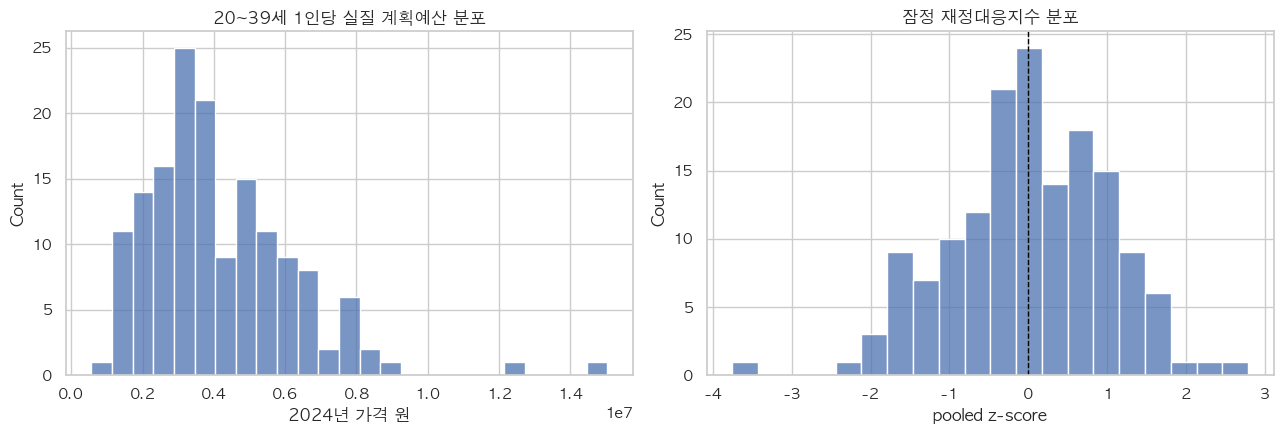

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=fiscal_panel,
    x="20_39세_1인당_실질예산_원",
    bins=25,
    ax=axes[0],
)
axes[0].set_title("20~39세 1인당 실질 계획예산 분포")
axes[0].set_xlabel("2024년 가격 원")

sns.histplot(data=fiscal_panel, x="재정대응지수_z", bins=20, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("잠정 재정대응지수 분포")
axes[1].set_xlabel("pooled z-score")

plt.tight_layout()
plt.show()

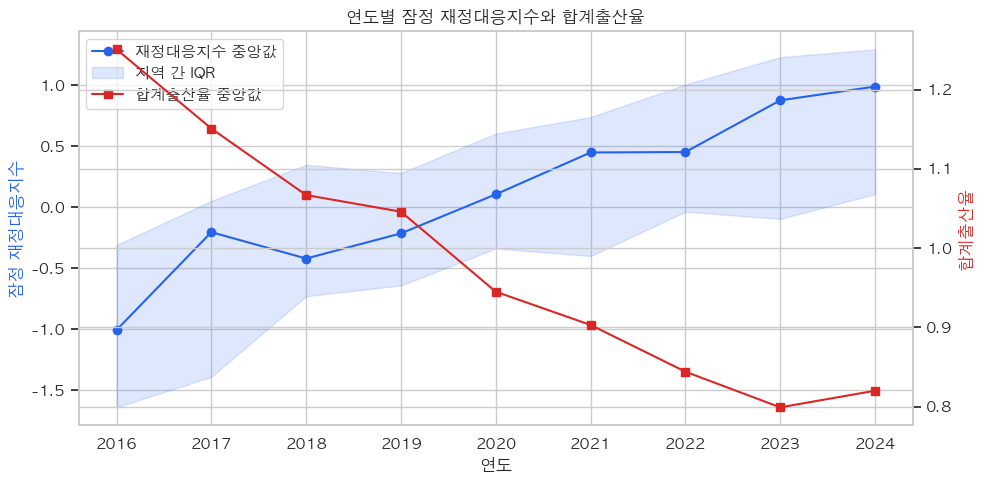

In [9]:
year_summary = fiscal_panel.groupby("연도", as_index=False).agg(
    재정대응지수_중앙값=("재정대응지수_z", "median"),
    재정대응지수_Q1=("재정대응지수_z", lambda values: values.quantile(0.25)),
    재정대응지수_Q3=("재정대응지수_z", lambda values: values.quantile(0.75)),
    합계출산율_중앙값=("합계출산율", "median"),
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(
    year_summary["연도"],
    year_summary["재정대응지수_중앙값"],
    marker="o",
    color="#2563eb",
    label="재정대응지수 중앙값",
)
ax1.fill_between(
    year_summary["연도"],
    year_summary["재정대응지수_Q1"],
    year_summary["재정대응지수_Q3"],
    color="#2563eb",
    alpha=0.15,
    label="지역 간 IQR",
)
ax1.set_xlabel("연도")
ax1.set_ylabel("잠정 재정대응지수", color="#2563eb")

ax2 = ax1.twinx()
ax2.plot(
    year_summary["연도"],
    year_summary["합계출산율_중앙값"],
    marker="s",
    color="#dc2626",
    label="합계출산율 중앙값",
)
ax2.set_ylabel("합계출산율", color="#dc2626")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="best")
ax1.set_title("연도별 잠정 재정대응지수와 합계출산율")
plt.tight_layout()
plt.show()

### 6. 1차 재정반응성 모형 분석 표본 구성

회귀 실행 전 시차 변수와 분석 가능 표본을 확인한다.

In [10]:
response_model_columns = [
    "지역",
    "연도",
    "재정대응지수_z",
    "총액기준_재정대응지수_z",
    "log1인당실질예산_전년변화",
    "계획예산_총세출비율_pct",
    "log1p_계획예산_총세출비율",
    "직전1년_출산율하락도",
    "전년도_합계출산율",
    "원자료_누락주의",
]
response_model_sample = response_panel.dropna(subset=["재정대응지수_z", "직전1년_출산율하락도"])[
    response_model_columns
].copy()

assert response_model_sample["연도"].min() == START_YEAR + 2
assert response_model_sample["지역"].nunique() == EXPECTED_REGIONS
assert not response_model_sample.duplicated(PANEL_KEY).any()

model_sample_qa = pd.Series(
    {
        "가용관측치": len(response_model_sample),
        "지역수": response_model_sample["지역"].nunique(),
        "최초연도": response_model_sample["연도"].min(),
        "최종연도": response_model_sample["연도"].max(),
        "원자료누락주의": response_model_sample["원자료_누락주의"].notna().sum(),
    },
    name="값",
)
FISCAL_PANEL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fiscal_panel.to_csv(FISCAL_PANEL_OUTPUT_PATH, index=False)
response_model_sample.to_csv(MODEL_SAMPLE_OUTPUT_PATH, index=False)

assert FISCAL_PANEL_OUTPUT_PATH.exists()
assert MODEL_SAMPLE_OUTPUT_PATH.exists()

display(model_sample_qa.to_frame())
display(response_model_sample.head())
print(f"재정대응지수 패널 저장: {FISCAL_PANEL_OUTPUT_PATH}")
print(f"회귀 분석 표본 저장: {MODEL_SAMPLE_OUTPUT_PATH}")

,값
가용관측치,119
지역수,17
최초연도,2018
최종연도,2024
원자료누락주의,2


,지역,연도,재정대응지수_z,총액기준_재정대응지수_z,log1인당실질예산_전년변화,계획예산_총세출비율_pct,log1p_계획예산_총세출비율,직전1년_출산율하락도,전년도_합계출산율,원자료_누락주의
2,강원,2018,-0.1469,-0.4870,-0.1012,10.5437,2.4461,0.1140,1.1230,원자료에 자체사업 상세가 없어 세부사업 합계가 과소대표될 수 있음
3,강원,2019,0.6978,-0.0409,0.4238,14.4458,2.7373,0.0560,1.0670,NaN
4,강원,2020,0.5494,-0.1400,-0.0744,12.1416,2.5758,-0.0150,1.0820,NaN
5,강원,2021,1.1147,0.1463,0.2836,15.2376,2.7873,0.0460,1.0360,NaN
6,강원,2022,0.2616,-0.3505,-0.4280,9.5589,2.3570,0.0570,0.9790,NaN


재정대응지수 패널 저장: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/data/processed/analysis/2016-2024_재정대응지수_패널.csv
회귀 분석 표본 저장: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/data/processed/analysis/2018-2024_재정반응성_회귀표본.csv


### 7. 산식 대안별 지역·연도 고정효과 모형

직전 1년 출산율 하락도를 설명변수로 두고 지역·연도 고정효과를 적용한다.
인구당·총액 지수와 함께 총세출 대비 계획예산 비율 및 그 `log1p` 변환을 비교한다.
주 분모는 지역통합 3개 회계 당초예산 순계이며 모든 산식은 같은 표본을 사용한다.
표준오차는 지역 단위로 군집화하고 유한표본 보정과 t분포 추론을 사용한다.
17개 군집은 여전히 적으므로 p값보다 계수 방향·신뢰구간·민감도 결과를 함께 본다.

In [11]:
model_outcomes = {
    "인구당지수": "재정대응지수_z",
    "총액지수": "총액기준_재정대응지수_z",
    "1인당예산전년변화": "log1인당실질예산_전년변화",
    "총세출비율_pct": "계획예산_총세출비율_pct",
    "총세출비율_log1p": "log1p_계획예산_총세출비율",
}
fixed_effects_results, fitted_models = run_fiscal_response_models(
    response_model_sample,
    outcomes=model_outcomes,
)

assert len(fixed_effects_results) == len(model_outcomes) * 2
assert fixed_effects_results["지역수"].eq(EXPECTED_REGIONS).all()
assert fixed_effects_results["연도수"].eq(END_YEAR - START_YEAR - 1).all()
assert fixed_effects_results["관측치"].isin([117, 119]).all()
assert np.isfinite(
    fixed_effects_results[
        ["계수", "군집표준오차", "p값", "95%신뢰구간_하한", "95%신뢰구간_상한"]
    ].to_numpy()
).all()

fixed_effects_results.to_csv(MODEL_RESULT_OUTPUT_PATH, index=False)
assert MODEL_RESULT_OUTPUT_PATH.exists()

display_columns = [
    "모형",
    "계수",
    "군집표준오차",
    "p값",
    "95%신뢰구간_하한",
    "95%신뢰구간_상한",
    "관측치",
    "지역수",
    "연도수",
]
display(fixed_effects_results[display_columns].round(4))
print(f"고정효과 모형 결과 저장: {MODEL_RESULT_OUTPUT_PATH}")

,모형,계수,군집표준오차,p값,95%신뢰구간_하한,95%신뢰구간_상한,관측치,지역수,연도수
0,인구당지수_전체표본,0.1821,0.7760,0.8175,-1.4630,1.8271,119,17,7
1,총액지수_전체표본,0.1987,0.4509,0.6653,-0.7572,1.1546,119,17,7
2,1인당예산전년변화_전체표본,-0.0921,0.6459,0.8883,-1.4614,1.2771,119,17,7
3,총세출비율_pct_전체표본,8.8352,9.0748,0.3447,-10.4026,28.0729,119,17,7
4,총세출비율_log1p_전체표본,0.2930,0.3959,0.4699,-0.5462,1.1322,119,17,7
5,인구당지수_누락주의제외,0.2899,0.7170,0.6913,-1.2301,1.8099,117,17,7
6,총액지수_누락주의제외,0.2526,0.4162,0.5524,-0.6297,1.1349,117,17,7
7,1인당예산전년변화_누락주의제외,-0.0738,0.6447,0.9103,-1.4404,1.2928,117,17,7
8,총세출비율_pct_누락주의제외,10.0954,8.2281,0.2376,-7.3474,27.5382,117,17,7
9,총세출비율_log1p_누락주의제외,0.3373,0.3730,0.3793,-0.4535,1.1281,117,17,7


고정효과 모형 결과 저장: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/data/processed/analysis/2018-2024_재정반응성_고정효과_결과.csv


## 해석 및 다음 단계

- 주 지수는 20~39세 1인당 실질예산 기준 잠정 지수다.
- 총액 기준 지수와 총세출 대비 계획예산 비율은 산식 민감도 계열로 함께 보존한다.
- 시차 분석 가용 표본은 119개다.
- 지수와 시차 산출은 `src.features.analysis_panel`의 공통 함수를 사용한다.
- 재정반응성 기본모형은 지역·연도 고정효과와 지역 군집표준오차를 사용한다.
- 총세출 비율 계수는 전체표본과 누락주의 제외 표본 모두 양(+)이지만 95% 신뢰구간이 0을 포함한다.
- 모든 산식의 95% 신뢰구간이 0을 포함해 이전 출산율 하락 뒤 재정대응 증가 관계를 확인하지 못했다.
- 이는 관계가 없다는 증거가 아니며 계수는 인과효과가 아닌 조건부·시차적 관계다.